# Liver Disease Classification Modeling - Final Project
Maddie Emert, Ava Lawless, Maya Clifford

## Question and Background

### Our Question:

How accurately can we predict whether a patient has liver disease using clinical biomarkers, and which features are most strongly associated with the presence of the disease?

### Background Information:

Liver disease is an increasing global health concern, influenced by factors such as alcohol consumption, chronic hepatitis infections, and obesity. The detection of liver disease in its early stages is critical, as conditions progress silently and significantly in advanced stages. To assess liver function, clinical biomarkers such as bilirubin levels, liver enzymes, and protein concentrations are used in medical settings, though the interpretation of these biomarkers can be complex. Their unique relationships with the presence of liver disease may also not be immediately identifiable without further analysis, which is what our question aims to address.

For this project, we used a Kaggle dataset of liver disease patient records from the northeast region of Andhra Pradesh, India. This dataset includes demographic information, such as age and gender, along with various biomarkers related to liver function. The dataset is intentionally suited for machine learning and classification tasks, equipped with labeled outcomes indicating whether or not each patient has the disease. Our goal is to explore how data-driven methods can support medical diagnosis while considering the variability in biomarker levels and potential differences across individuals.

In order to find an answer to our central question, we will apply machine learning methods to evalute the relationship between biomarkers and disease status, implementing models of Logistic Regression and Decision Trees. We intend on evaluting both predictive performance and the most informative variables, providing insight into which clinical measurements are most indicative of liver disease. This will be assessed using a variety of performance metrics that will reveal which model best serves our purpose. Overall, we want to be able to connect our findings back to real-world medical relevance, ultimately contributing to liver disease research.

In [1]:
# Imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RepeatedStratifiedKFold, cross_val_score,
    cross_validate, GridSearchCV
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.tree import DecisionTreeClassifier, export_graphviz

sns.set_style('whitegrid')

### Read in the data

In [2]:
# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)
# List files in the downloaded dataset directory
print(os.listdir(path))

Using Colab cache for faster access to the 'liver-patient-dataset' dataset.
Path to dataset files: /kaggle/input/liver-patient-dataset
['liver_patient_dataset.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "liver_patient_dataset.csv"))
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Data Cleaning and Preparation

In [4]:
# Replace the target variable with 1 for positive class (liver disease) and 0 for negative class (no liver disease)
df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})

/tmp/ipykernel_43964/3278628130.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})


In [5]:
# Change the name of the selector column to target
df.rename(columns={'Selector':'Target'}, inplace=True)
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
# Calculate the prevalence
prevalence = np.mean(df.Target) * 100
print(f'The prevalence is {prevalence:.2f}%')

The prevalence is 71.36%


In [7]:
# Check for null values
print(df.isna().sum())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Target       0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Target     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [9]:
# Print the summary statistics of the numeric data
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


From looking at the summary statistics, TB, DB, Alkphos, Sgpt, and Sgot all need to be transformed so they have a more normal distribution. They are all clearly very skewed, as they have standard deviations that are much greater than the means and have max values that are much higher than the number that's the 75th percentile of the column. These are all skewed to the right, so we will use log transformations on the columns.

In [10]:
to_transform = ['TB',	'DB',	'Alkphos',	'Sgpt',	'Sgot']
names = ['TB_log',	'DB_log',	'Alkphos_log',	'Sgpt_log',	'Sgot_log']
df[names] = np.log(df[to_transform])
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,-0.356675,-2.302585,5.231109,2.772589,2.890372
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,2.388763,1.704748,6.549651,4.158883,4.605170
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1.987874,1.410987,6.194405,4.094345,4.219508
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0.000000,-0.916291,5.204007,2.639057,2.995732
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1.360977,0.693147,5.273000,3.295837,4.077537


In [11]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551,0.463421,-0.650373,5.493417,3.751829,3.956771
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490,1.018527,1.326394,0.528128,0.900236,0.997381
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000,-0.916291,-2.302585,4.143135,2.302585,2.302585
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000,-0.223144,-1.609438,5.167635,3.135494,3.218876
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000,0.000000,-1.203973,5.337538,3.555348,3.737670
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000,0.955511,0.262364,5.697093,4.102609,4.465908
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000,4.317488,2.980619,7.654443,7.600902,8.502891


## Exploratory Data Analysis

### 1. Dataset Overview and Class Distribution

First, we want to examine the overall structure of the dataset and the distribution of the target variable: the presence of liver disease. 0 represents the negative class, and 1 represents the positive class. We see in the data cleaning process that this dataset contains 583 patient records with no missing values, making it already suitable for analysis.

One of our key initial findings is the clear class imbalance in the target variable. The prevelance reveals that approximately 71% of patients are in the positive class, meaning they have liver disease, while 29% are not. This imbalance is important to note as a possible limitation, as it may bias our models toward predicting the majority class, so this must be considered during model evaluation.

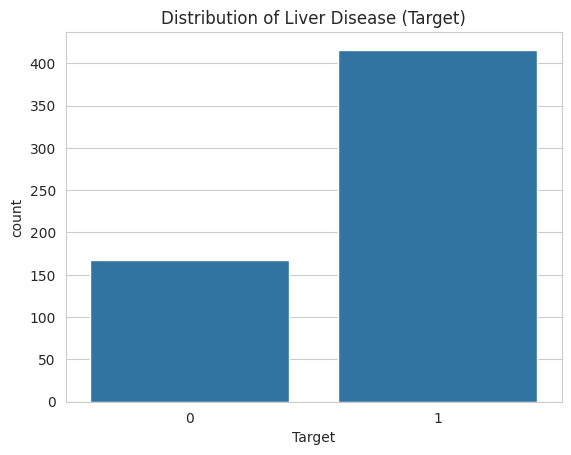

In [12]:
sns.countplot(x='Target', data=df)
plt.title("Distribution of Liver Disease (Target)")
plt.show()

This distribution suggests that liver disease is highly prevalent in the dataset. As a result, accuracy alone may not be a sufficient evaluation metric, since a model could achieve high accuracy by simply predicting the majority class.

### 2. Distribution of Key Biomarkers

Our initial summary statistics revealed that several clinical biomarkers are heavily right-skewed with extreme outliers, particularly TB, DB, Alkphos, Sgpt, and Sgot. This is not unusual in medical data, where abnormal biomarker levels can face a significant increase in diseased patients. In order to address this, we applied log transformations on these variables to make comparisons across the data much clearer. This compresses extreme values, making the distributions more symmetric and interpretations more obvious.

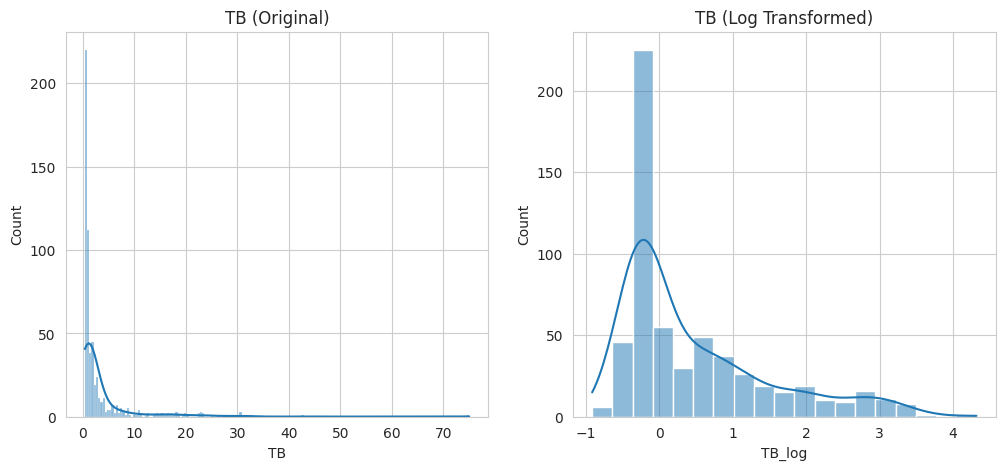

In [13]:
# Example of visual log transformation: TB
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['TB'], ax=axes[0], kde=True)
axes[0].set_title("TB (Original)")

sns.histplot(df['TB_log'], ax=axes[1], kde=True)
axes[1].set_title("TB (Log Transformed)")

plt.show()

The log transformation reduces skewness and stabilizes variance, making these variables more suitable for our Logistic Regression and Decision Tree models, which typically assume more normally distributed input data.

### 3. Biomarkers vs Liver Disease

Since we primarily want to understand which variables are most informative, we must compare biomarker distributions in the context of patients with and without liver disease.

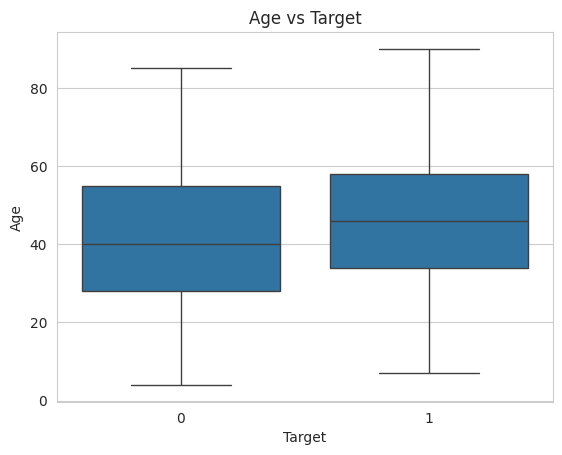

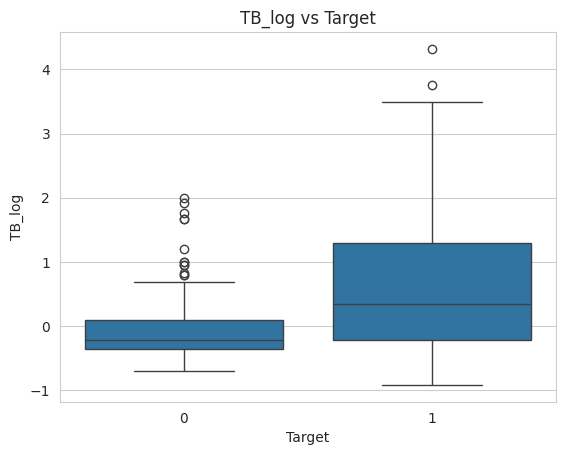

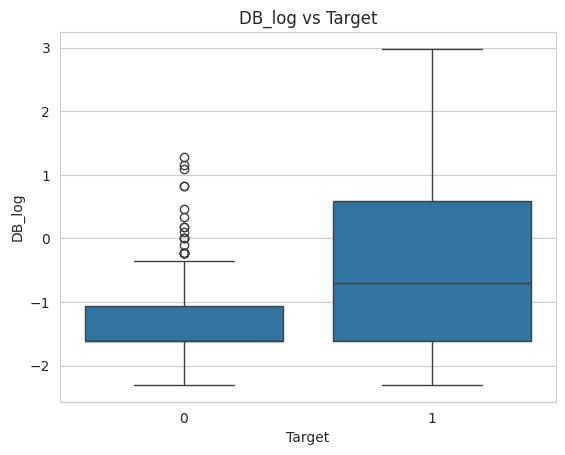

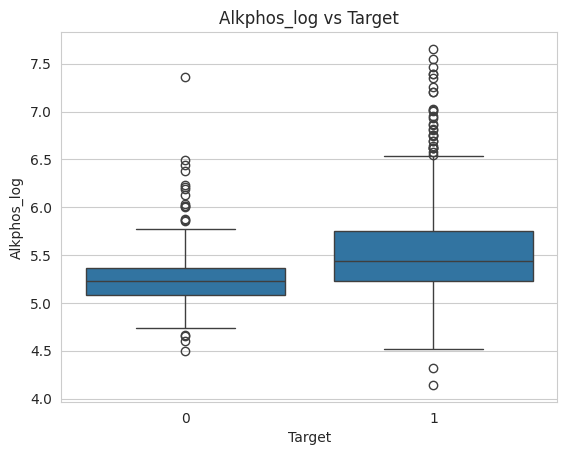

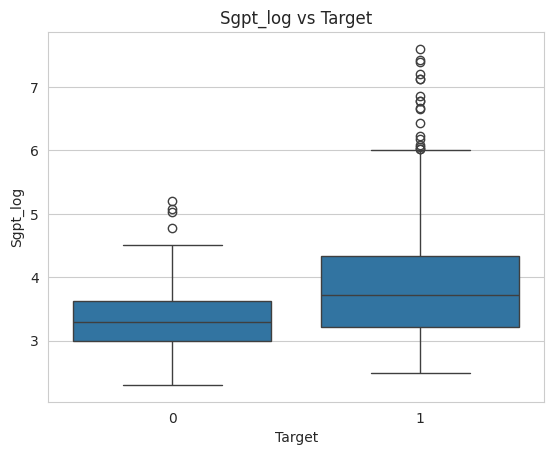

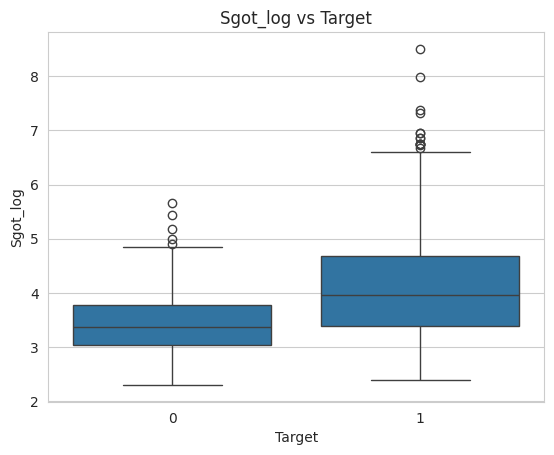

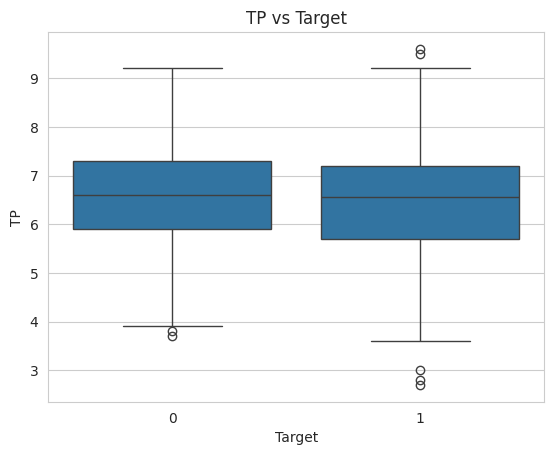

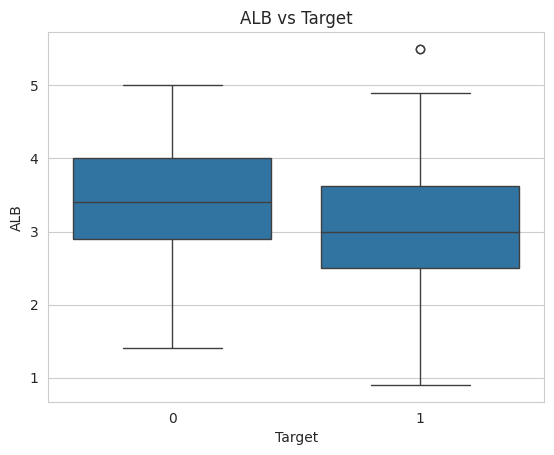

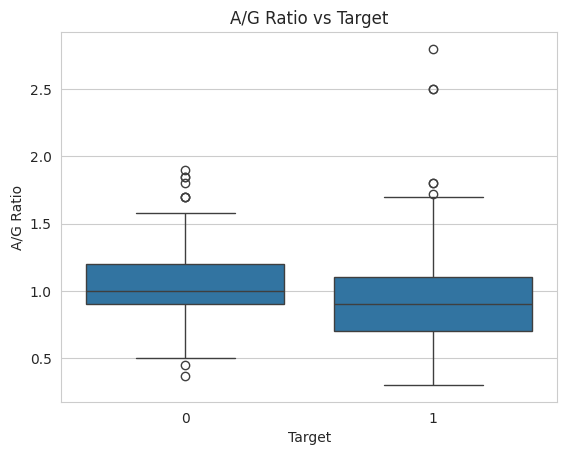

In [14]:
features = ['Age', 'TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']

for col in features:
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

The boxplots reveal that patients with liver disease consistently show higher levels of bilirubin and liver enzymes compared to those without. Protein-related markers like ALB and A/G Ratio appear slightly lower, reflecting impaired liver function, whereas age shows only a modest difference between groups. These distributional differences generally suggest that most of the features carry some predictive signal, with bilirubin and enzyme levels being the strongest.

### 4. Correlation Analysis

Next, we directly examine relationships between variables using a correlation matrix to identify redundancy and potential multicollinearity.

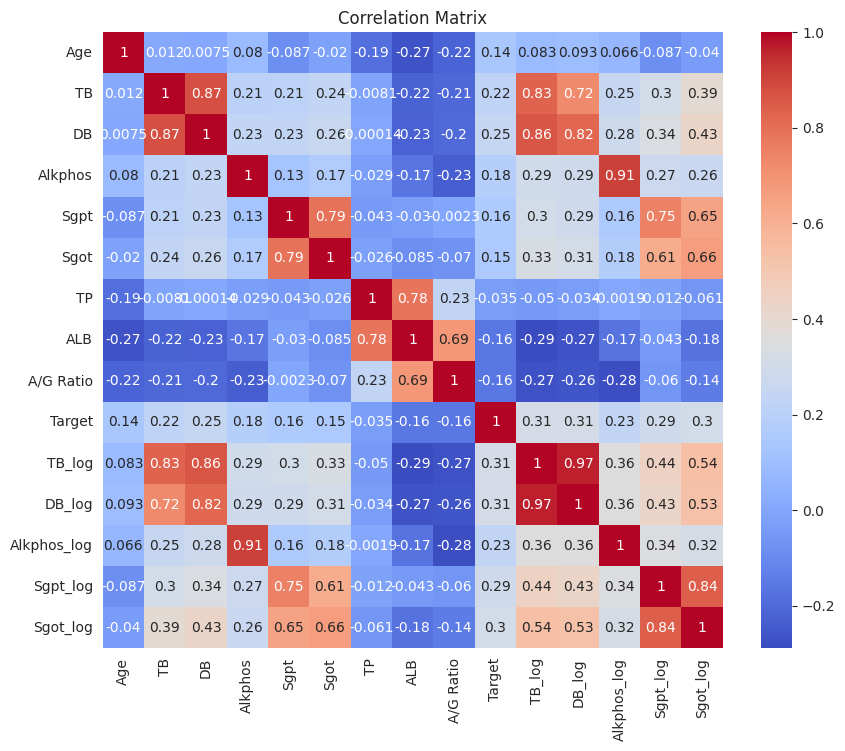

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals that several biomarkers are strongly correlated with one another. This most notably includes TB and DB (0.87), Sgpt and Sgot (0.79), and their log-transformed counterparts. This is to be expected given that these pairs measure closely related aspects of liver function. Similarly, ALB and A/G Ratio are moderately correlated (0.69), and TP and ALB share a strong relationship (0.78), suggesting some degree of redundancy among the protein markers.

With respect to the target variable, correlations are fairly modest across the board. DB_log and TB_log show the highest associations with liver disease (0.31 each), followed by Sgpt_log, Sgot_log, and Alkphos_log. Protein markers such as TP, ALB, and A/G Ratio show weak negative correlations with the target, which aligns with the boxplot results. Overall, no single feature is strongly predictive on its own, suggesting that liver disease classification would most likely benefit from combining multiple biomarkers rather than relying on any individual variable.

### 5. Demographic Insights

We also want to get a general idea of potentially beneficial demographic insights, which includes the variables age and gender.

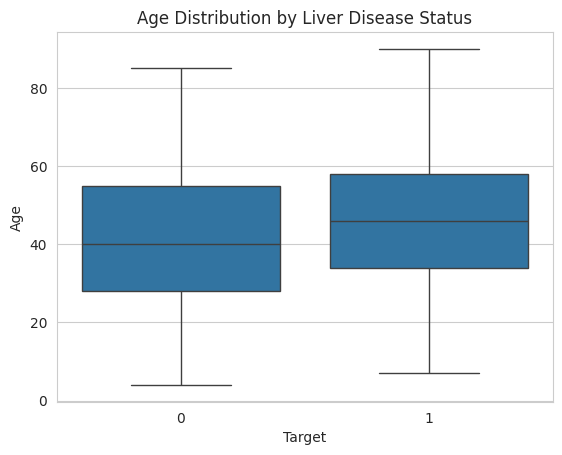

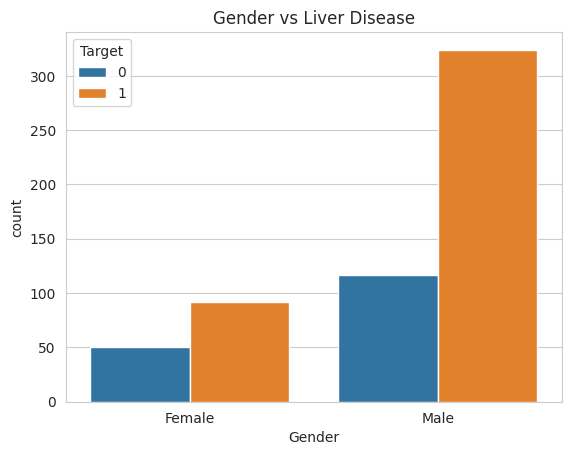

In [16]:
sns.boxplot(x='Target', y='Age', data=df)
plt.title("Age Distribution by Liver Disease Status")
plt.show()

sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Liver Disease")
plt.show()

We see that age may show a slight trend where older individuals are more likely to have liver disease, though some overlap exists.

We also see that the dataset is predominantly male at about 76%, which may introduce bias. Liver disease appears much more common among males in the dataset, but this may simply be a reflection of skewed sampling rather than a true population effect.

### 6. Key EDA Takeaways

This exploratory data analysis highlights several important patterns in the dataset. Liver disease is highly prevalent, resulting in class imbalance that must be accounted for in modeling. Certain biochemical markers, including total bilirubin (TB), direct bilirubin (DB), alkaline phosphatase (Alkphos), and liver enzymes (Sgpt and Sgot), are heavily right-skewed and required log transformation to improve distributions. The correlation analysis revealed strong relationships among a select few biomarkers, particularly TB & DB and Sgpt & Sgot, but much weaker relationships among the rest. No single variable is highly predictive of liver disease on its own, as most remain moderately correlated with the target, whether that be positively or negatively. Demographic variables of age and gender show relatively weak relationships.

Overall, these findings suggest our modeling process will benefit from combining multiple biochemical markers to predict liver disease, placing particular emphasis on bilirubin levels and liver enzymes as the most informative.

## Method: Logistic Regression Model

We are using logistic regression as one of our methods. Model 1 will be a logistic regression model with the original numeric variables instead of the log transformations so that we can compare the two.

In [17]:
# Logistic regression model with original variables
CATEGORICAL_1 = ['Gender']
NUMERIC_1     = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']
TARGET_1      = 'Target'

X = df[CATEGORICAL_1 + NUMERIC_1]
y = df[TARGET_1]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [18]:
# Create pipeline
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_1),
    ('num', 'passthrough', NUMERIC_1)
])

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m1.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB', 'DB', 'Alkphos',
                                                   'Sgpt', 'Sgot', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

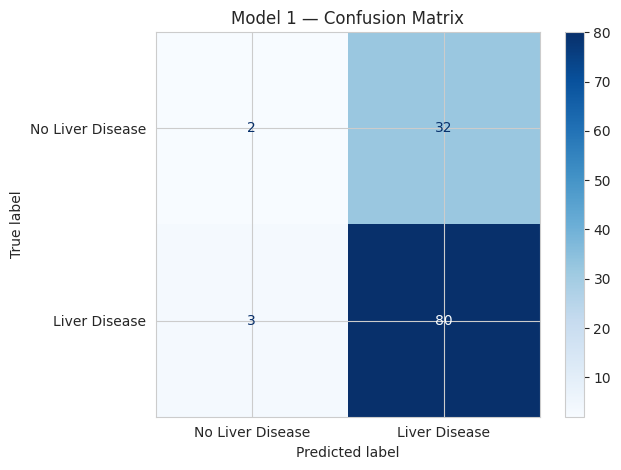

                  precision    recall  f1-score   support

No Liver Disease       0.40      0.06      0.10        34
   Liver Disease       0.71      0.96      0.82        83

        accuracy                           0.70       117
       macro avg       0.56      0.51      0.46       117
    weighted avg       0.62      0.70      0.61       117



In [19]:
# Create confusion matrix
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['No Liver Disease', 'Liver Disease']))

The confusion matrix has a very high number of false positives. 32 patients were misclassified as having liver disease when they actually didn't.

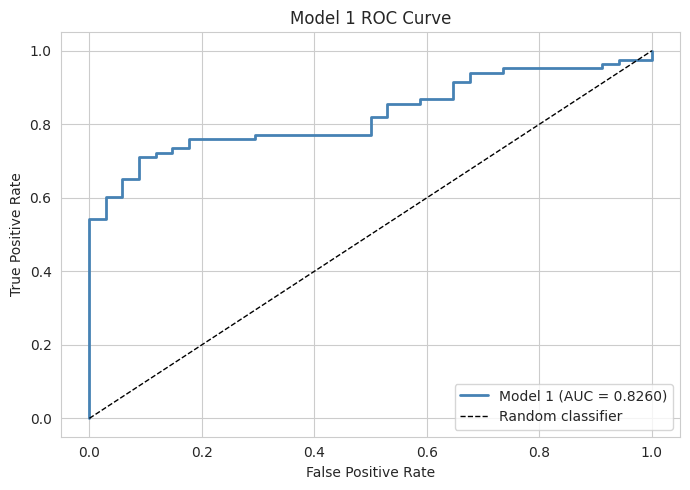

Model 1 ROC-AUC: 0.8260


In [20]:
# ROC curve
y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

The Model 1 ROC Curve shows that it has an ROC value of 0.8239, which isn't perfect, but pretty good. We'll make a second model with the log-transformed values to see if it changes anything.

In [21]:
# Now, we'll try it with the log-transformed variables in a new model
CATEGORICAL_2 = ['Gender']
NUMERIC_2     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']
TARGET_2      = 'Target'

X = df[CATEGORICAL_2 + NUMERIC_2]
y = df[TARGET_2]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [22]:
# Create pipeline
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_2),
    ('num', 'passthrough', NUMERIC_2)
])

pipe_m2 = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

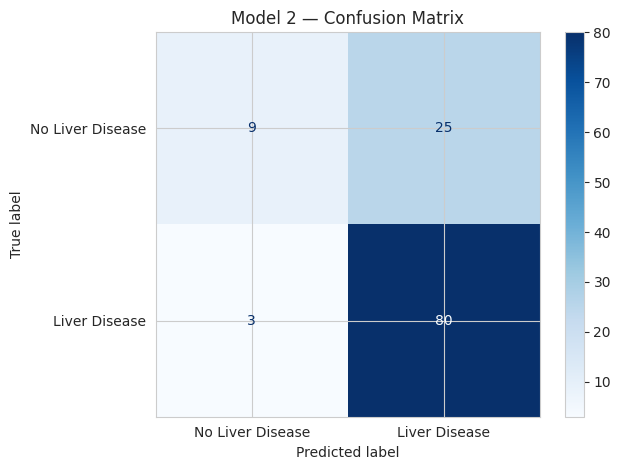

                  precision    recall  f1-score   support

No Liver Disease       0.75      0.26      0.39        34
   Liver Disease       0.76      0.96      0.85        83

        accuracy                           0.76       117
       macro avg       0.76      0.61      0.62       117
    weighted avg       0.76      0.76      0.72       117



In [23]:
# Create confusion matrix for Model 2
y_pred_m2 = pipe_m2.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2, target_names=['No Liver Disease', 'Liver Disease']))

Model 2 with the log-transformed variables reduced the number of false positives. However, the number of false negatives stayed the same.

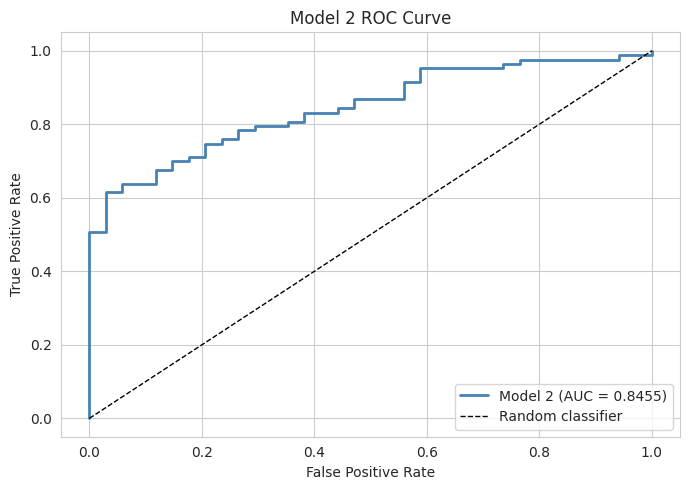

Model 2 ROC-AUC: 0.8455


In [24]:
# ROC curve for Model 2
y_proba_m2 = pipe_m2.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

Our ROC curve improved with the log-transformed variables.

From the correlation matrix of variables in the EDA section, there were some variables that were negatively correlated with the target variable. These variables were TP (-0.035), ALB (-0.16), and A/G Ratio (-0.16). We're going to drop these for the next model and see if that affects the correlation.

In [25]:
# Create train and test without the negatively-correlated variables
CATEGORICAL_3 = ['Gender']
NUMERIC_3     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log']
TARGET_3      = 'Target'

X = df[CATEGORICAL_3 + NUMERIC_3]
y = df[TARGET_3]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [26]:
# Create pipeline for Model 3
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_3),
    ('num', 'passthrough', NUMERIC_3)
])

pipe_m3 = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m3.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

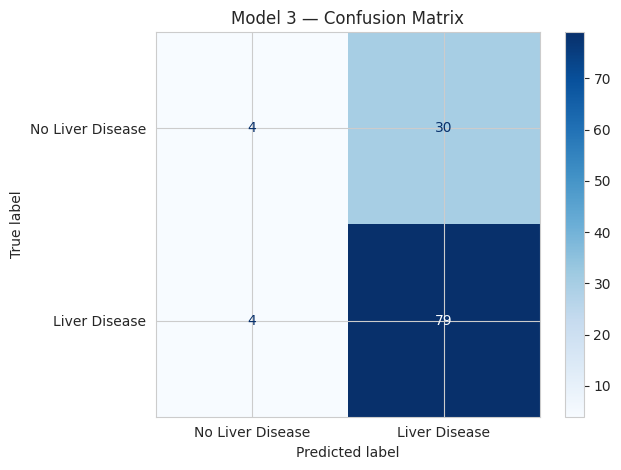

                  precision    recall  f1-score   support

No Liver Disease       0.50      0.12      0.19        34
   Liver Disease       0.72      0.95      0.82        83

        accuracy                           0.71       117
       macro avg       0.61      0.53      0.51       117
    weighted avg       0.66      0.71      0.64       117



In [27]:
# Create confusion matrix for Model 3
y_pred_m3 = pipe_m3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['No Liver Disease', 'Liver Disease']))

Removing the negatively-correlated variables actually increased the number of false negatives and it made the false positives much higher again.

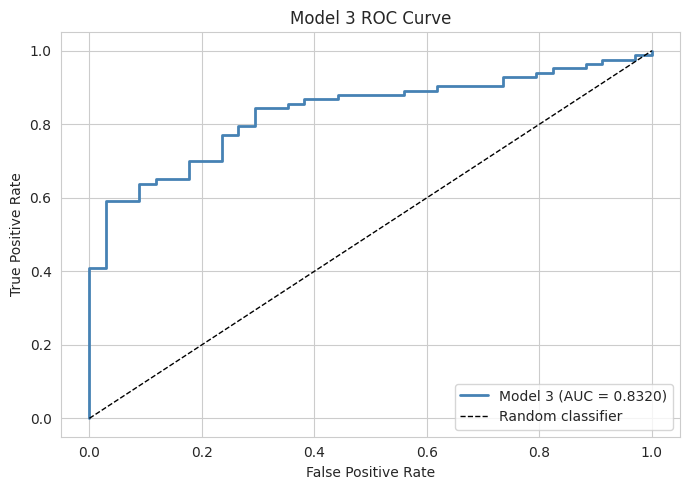

Model 3 ROC-AUC: 0.8320


In [28]:
# ROC curve for Model 3
y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

Removing the negatively-correlated variables did not help our model very much.

Thus far, Model 2 has given us the best ROC score. However, it's a pretty default model, so there are ways to improve it. Even though we applied the log transformations, the variables are not scaled, so we will scale them in the next model. Additionally, since the prevalence is 71.36%, it's imbalanced. We can balance it using class_weight = 'balanced'.

In [29]:
# Create model 4 with scaled variables, balanced weights, and adjusted C value
CATEGORICAL_4 = ['Gender']
NUMERIC_4     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']
TARGET_4      = 'Target'

X = df[CATEGORICAL_4 + NUMERIC_4]
y = df[TARGET_4]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [30]:
# One-hot encoding on categorical variable
preprocessor_m4 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_4),
    ('num', StandardScaler(), NUMERIC_4)
])

# Create pipeline and make class_weight='balanced'
pipe_m4 = Pipeline(steps=[
    ('prep',  preprocessor_m4),
    ('model', LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# Fit the model
pipe_m4.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender']),
                                                 ('num', StandardScaler(),
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    n_jobs=-1, random_state=42))])

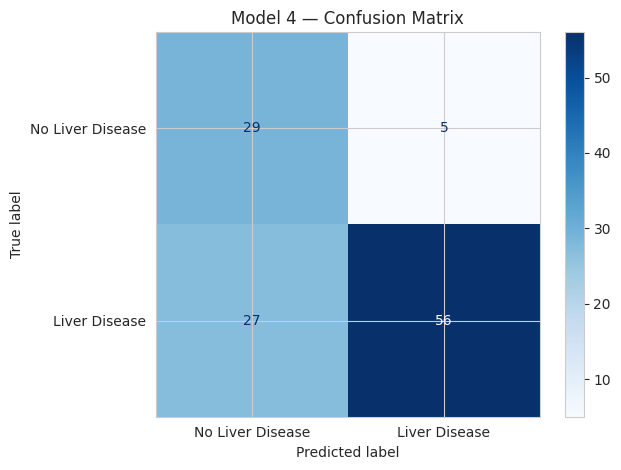

                  precision    recall  f1-score   support

No Liver Disease       0.52      0.85      0.64        34
   Liver Disease       0.92      0.67      0.78        83

        accuracy                           0.73       117
       macro avg       0.72      0.76      0.71       117
    weighted avg       0.80      0.73      0.74       117



In [31]:
# Create confusion matrix for Model 4
y_pred_m4 = pipe_m4.predict(X_test)
cm_m4 = confusion_matrix(y_test, y_pred_m4)
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m4, target_names=['No Liver Disease', 'Liver Disease']))

The adjustments we made actually worsened the model by a lot because it significantly increased the number of false negatives. However, it did drastically improve the number of true negatives. But if we are dealing with liver patients, it's very risky to misclassify patients as not having liver disease when they actually do.

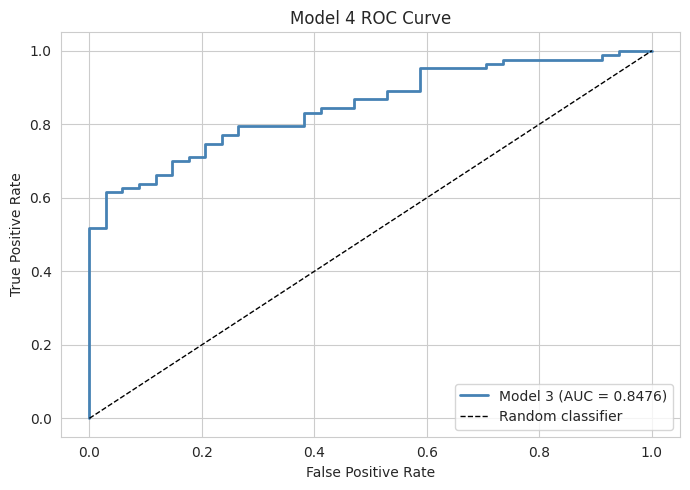

Model 4 ROC-AUC: 0.8320


In [32]:
# ROC curve for Model 4
y_proba_m4 = pipe_m4.predict_proba(X_test)[:, 1]
fpr_m4, tpr_m4, thresholds = roc_curve(y_test, y_proba_m4)
auc_m4 = roc_auc_score(y_test, y_proba_m4)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m4, tpr_m4, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m4:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 4 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 4 ROC-AUC: {auc_m3:.4f}")

The ROC score for this model is still lower than Model 2.

### Logistic Regression Conclusion

Out of the four logistic regression models, Model 2 (log-transformed variables, no elimination of any features) had the best ROC score of 0.8455. While it is not perfect, it falls into the "Good" category (0.8-0.9). This is impressive for a relatively small dataset. The best way to improve the model would be to have more data for it to train on, but for a small dataset, it is a good score. It is also the model with the fewest number of false negatives, which is good because that is what we want to reduce. It's better to have more false positives (accidentally diagnosing someone with liver disease when they actually don't have it) than to have more false negatives (accidentally saying someone does not have liver disease when they actually do) in the context of disease data, as it puts fewer lives at risk.

## Method: Decision Tree Model

We are using decision trees as our other method.

In [33]:
# Make the X data frame have all the features in the original data frame except for the target
X = df.drop(columns='Target')

# y is only the target variable
y = df['Target']

In [34]:
# Split X and y into train and test sets with an 80/20 split
# Also stratify them based on y so the prevalence is preserved
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

We want to use Grid Search CV to find the best parameter values for our initial model out of max depth, min samples split, min samples leaf, and max leaf nodes.

In [35]:
# Initalize the cross-validation for scoring which will have 10 folds repeated 5 times
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats=5, random_state=42)

In [36]:
# Set the metrics that we want to score the different models on to determine the best parameters
scoring = ['roc_auc','recall','balanced_accuracy']

In [37]:
# Set the parameters we want to test with grid search
# classifier max depth is how many edges can be between the root node and the deepest leaf node
param={"classifier__max_depth" : [1,2,3,4,5,6],
       # min samples split is the minimum number of samples needed in a node for it to be able to split, meaning if there are less
       # samples in a node than the min samples split, then it will become a leaf node regardless of if the model thinks all the samples
       # have the same classification
        "classifier__min_samples_split":[5,10,15,20,25],
       # min samples leaf is the minimum number of samples needed in each leaf node, preventing leaf nodes with only one sample in them
       # which could lead to overfitting
        "classifier__min_samples_leaf":[5,10,15,20,25],
       # max leaf nodes is the maximum number of leaf nodes the model can have; a lower number here can also prevent overfitting
        "classifier__max_leaf_nodes":[10,20,30,40,50],
      }

In [38]:
# Define a preprocessor to handle categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('gender_encoder', OneHotEncoder(), ['Gender']) # one hot encode the gender column to make it numeric
    ],
    remainder='passthrough' # keep other columns as they are since they don't need to be transformed
)

In [39]:
# Make a pipeline with the preprocessor step and a decision tree with no parameters set except for the random state
#pipe = Pipeline([
#    ('preprocessor', preprocessor),
#    ('classifier', DecisionTreeClassifier(random_state=42))
#])

# Use grid search on the pipeline with the specified parameters, scoring, and the cross-validation that was set before
# It will also refit the model on the best parameters according to the ROC AUC score
#search = GridSearchCV(pipe, param, scoring=scoring, cv=kf, refit='roc_auc')

# Do the search on our training data
#model = search.fit(X_train, y_train)

# Since this cell takes a while to run, comment it out as the best model is initalized with the correct parameters below

In [40]:
# Retrieve the model with the best parameters and print out what those parameters are
#best = model.best_estimator_
#print(best)

In [41]:
# Make the model without needing to run grid search cv again by putting in the parameters printed above (saves time rerunning the notebook)
model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5, random_state=42))
])
# Fit this model to the training data
model = model_pipe.fit(X_train, y_train)

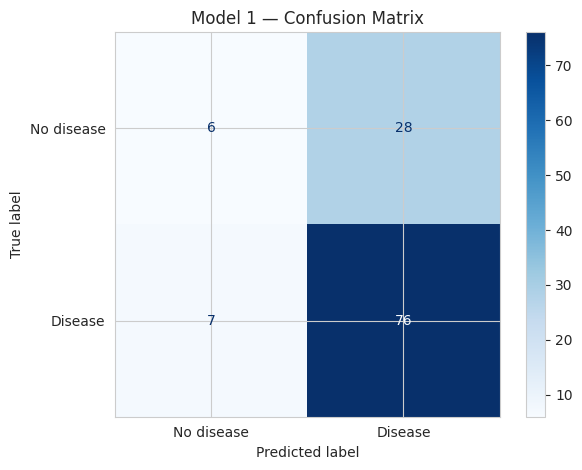

In [42]:
# Make the confusion matrix for this best model
# Predict the target varaible for the test data using our model
pred = model.predict(X_test)
# Make the confusion matrix of the actual and predicted values
cm_m1 = confusion_matrix(y_test, pred)
# Make a variable that holds the display of the confusion matrix made above
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [43]:
# Print the classification report
print(classification_report(y_test, pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.46      0.18      0.26        34
     Disease       0.73      0.92      0.81        83

    accuracy                           0.70       117
   macro avg       0.60      0.55      0.53       117
weighted avg       0.65      0.70      0.65       117



From looking at the confusion matrix and classification report for the model, we can see that it does pretty well on recall for the positive class (0.92), meaning that it correctly identifies most of the patients with liver disease as having liver disease. This can also be seen in the confusion matrix with how out of the patients that actually had liver disease in the test set, it correctly predicted 78 of them and only had 7 false negatives. The precision on the positive class, or how many of the patients that were predicted to have liver disease actually have it, is also slightly greater than the prevalence (being 0.73), which is also helpful. Where this model is lacking, however, is with both recall and precision on the negative class, but especially with recall. It only predicted that 13 of the 117 patients in the test set didn't have liver disease and was wrong about 7 of them, while also incorrectly classifying 28 patients who didn't have liver disease as having it. This indicates that we could maybe try balancing the class weights, as patients without liver disease made up less than 30% of the training data.

In [44]:
# Get the AUC score
# Get the probabilities that the model gave each data point in the test set to be in the positive class
y_test_proba = model.predict_proba(X_test)[:,1]
# Get the AUC score for the test set
test_auc  = metrics.roc_auc_score(y_test, y_test_proba)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7456



ROC Curve (Test Set):


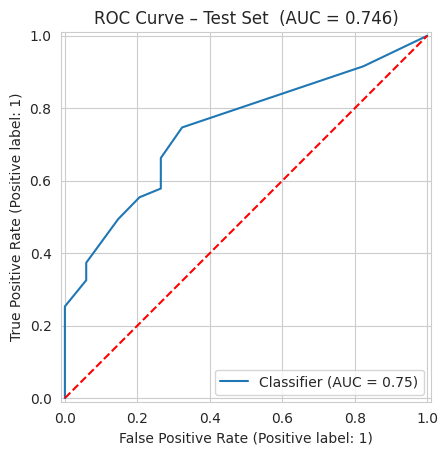

In [45]:
# Plot the ROC curve
print('\nROC Curve (Test Set):')
# Make the ROC curve display using the actual values and the probabilities the model assigned each data point to be in each class
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba)
# Make the red dotted line that runs from the bottom left to top right corner of the graph, representing random guessing
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

The AUC score is about 0.75, showing that the model is better than random guessing, but is only slightly higher than the prevalence, which is what the accuracy would be if the model guesses everyone to be in the positive class. We can also see that the ROC curve is not in the top left corner of the graph, which is where it would be if the model was more accurate, but it is still above the red line that represents random guessing.

We now want to make a new model with balanced class weights and see if that helps.

In [46]:
# Try balancing class weights so that there are less false positives
# Make the same pipeline as before, but add class_weight='balanced' in the decision tree
# This will mean that the decision tree weights the classes equally in training, so it will put more stake into the data points in the
# negative class since they were only 30% of the data
model2_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5, class_weight = 'balanced',
                                          random_state=42))
])
# Fit this new pipeline
model2 = model2_pipe.fit(X_train, y_train)

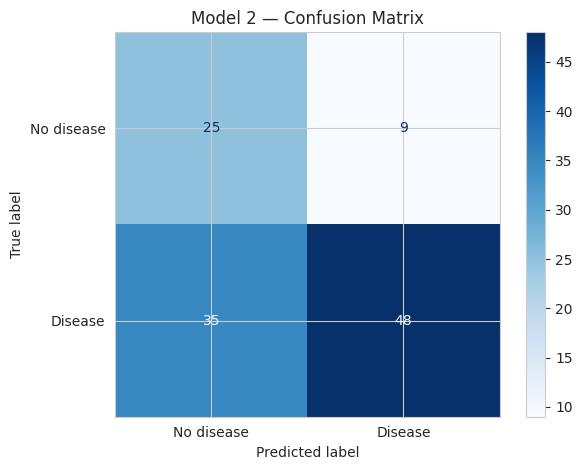

In [47]:
# Make the confusion matrix for the balanced class weights
# Get the predicted classifications for the test set from the model
pred2 = model2.predict(X_test)
# Make the confusion matrix comparing the actual and predicted values
cm_m2 = confusion_matrix(y_test, pred2)
# Make a variable that holds the display of the confusion matrix made above
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [48]:
# Print the classification report
print(classification_report(y_test, pred2, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.42      0.74      0.53        34
     Disease       0.84      0.58      0.69        83

    accuracy                           0.62       117
   macro avg       0.63      0.66      0.61       117
weighted avg       0.72      0.62      0.64       117



From looking at this confusion matrix and classification report, we can see that the model is predicting much more patients to be in the negative class (not have liver disease), but it's still not very accurate in these predictions. The precision on the positive class and recall on the negative class both increased with balanced class weights, but the recall on the negative class decreased signifigantly, which is problematic. With this model, 35 out of 117 patients are incorrectly classified as not having liver disease when they actually do, which would be detrimental to their care. Thus, although this model is better at correctly predicting patients that don't have liver disease, that isn't worth the increased number of false negatives, which are much worse than false positives. Thus, the first model should be used instead of this one because it had much less false negatives, meaning higher recall on the positive class.

In [49]:
# Get the AUC score
y_test_proba2 = model2.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba2)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7381



ROC Curve (Test Set):


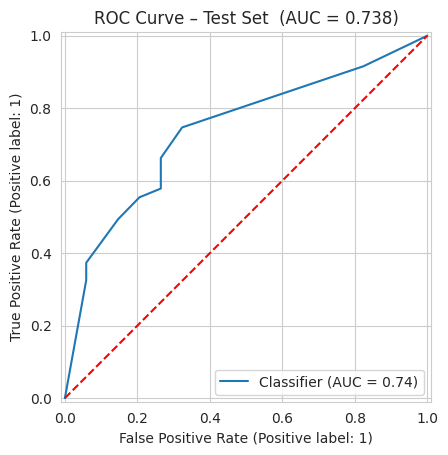

In [50]:
# Plot the ROC curve
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba2)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

We can also see that the AUC score went down slightly when the model had balanced class weights, which is another piece of evidence that this model isn't as useful as the first one.

We now want to try finding the best min impurity decrease to see if that changes the model.

In [51]:
# Try the grid search with the min impurity decrease
# This is how much a split must improve the purity to be accepted, meaning that a higher one can prevent overfitting
# Set the values of min impurity decrease that we want to test
param={"classifier__min_impurity_decrease":[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002]}

In [52]:
# Make the pipeline with the parameters from our best model earlier already set
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5,random_state=42))
])

# Do the search on the values of the min impurity decrease with the scoring and cross-validation set above
search = GridSearchCV(pipe, param, scoring=scoring, cv=kf, refit='roc_auc')

# Do the search on the training data to get the best value for min impurity decrease
model = search.fit(X_train, y_train)

In [53]:
# Make and print the model with the best parameter value
model3 = model.best_estimator_
print(model3)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


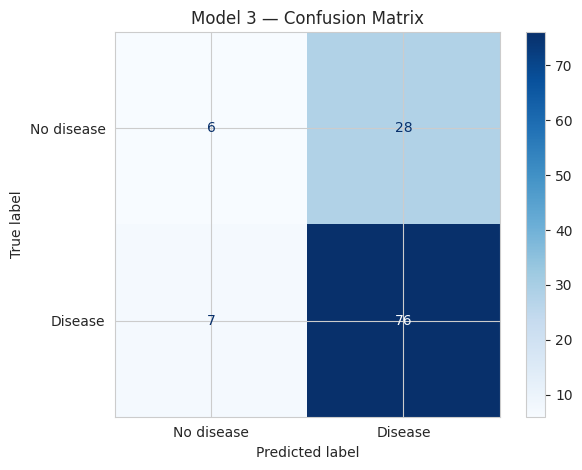

In [54]:
# Make the predictions on the test set
pred3 = model3.predict(X_test)
# Make the confusion matrix comparing the actual and predicted values
cm_m3 = confusion_matrix(y_test, pred3)
# Make a variable that holds the display of the confusion matrix made above
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [55]:
# Print the classification report
print(classification_report(y_test, pred3, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.46      0.18      0.26        34
     Disease       0.73      0.92      0.81        83

    accuracy                           0.70       117
   macro avg       0.60      0.55      0.53       117
weighted avg       0.65      0.70      0.65       117



In [56]:
# Get the AUC score
y_test_proba3 = model3.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba3)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7456



ROC Curve (Test Set):


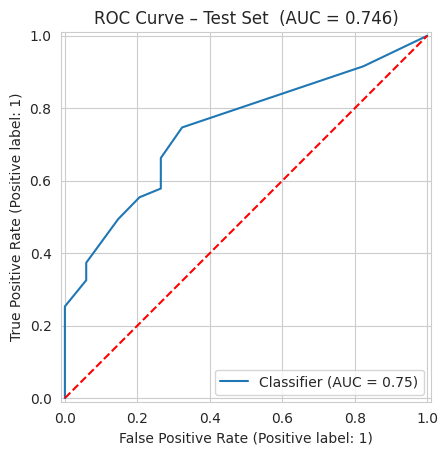

In [57]:
# Plot the ROC curve
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba3)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

We can see from the confusion matrix, classification report, ROC curve, and AUC score that changing the min impurity decrease doesn't improve any of the metrics on the test set; however, it also doesn't make any of them worse. Thus, we'll keep this model as it may be better on larger datasets.

We will now run Grid Search CV again, this time on the splitter, max features, and the ccp alpha.

In [58]:
# Set the parameters that we want to test and the values we want to test
# Splitter determines whether the model will look at all possible split points (best) or a random subset of split points (random)
# to determine the best split for each node
# Random is faster and can prevent overfitting, but might lead to lower accuracy
param={"classifier__splitter":["best","random"],
       # max features determines the maximum number of features the model can consider when looking for the best split at each node
       "classifier__max_features":["log2","sqrt",None],
       # ccp alpha is the penalty for complexity, meaning that the higher the alpha, the more nodes the tree is likely to remove while pruning
       # after fitting the model
       "classifier__ccp_alpha" :[.001, .01, .1]
       }

In [59]:
# Make the pipeline with the best features from earlier specified in the decision tree
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_impurity_decrease=0.0005,
                                          min_samples_leaf=25, min_samples_split=5, random_state=42))
])

# Do grid search cv on the pipeline looking through the 3 parameters shown above
search = GridSearchCV(pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

# Fit the search on the training data
model = search.fit(X_train, y_train)

In [60]:
# Retrieve and print the model with the best parameters according to the search above
model4 = model.best_estimator_
print(model4)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(ccp_alpha=0.001, max_depth=4,
                                        max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


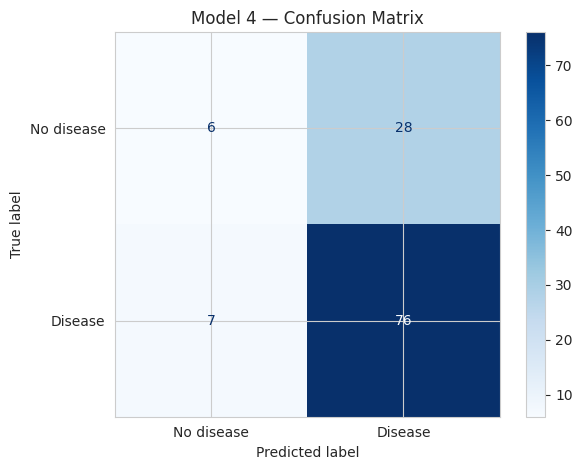

In [61]:
# Make the confusion matrix for this best model
# Get the predictions for the test set with model 4
pred4 = model4.predict(X_test)
# Make a confusion matrix of the predicted and actual values
cm_m4 = confusion_matrix(y_test, pred4)
# Make a variable that holds the display of the confusion matrix made above
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

We can see from this confusion matrix that the new model is just predicting every patient to have liver disease. This maximizes recall; however, it means that the model isn't useful at all, so we won't use this one. We can try balancing class weights while running the grid search to see if that improves the model since it should stop it from predicting every patient to have liver disease.

In [62]:
# Make the pipeline with the best features from earlier specified in the decision tree
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_impurity_decrease=0.0005,
                                          min_samples_leaf=25, min_samples_split=5, class_weight='balanced',random_state=42))
])

# Do grid search cv on the pipeline looking through the 3 parameters shown above
search = GridSearchCV(pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

# Fit the search on the training data
model = search.fit(X_train, y_train)

In [63]:
# Retrieve and print the model with the best parameters according to the search above
model5 = model.best_estimator_
print(model5)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(ccp_alpha=0.001,
                                        class_weight='balanced', max_depth=4,
                                        max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


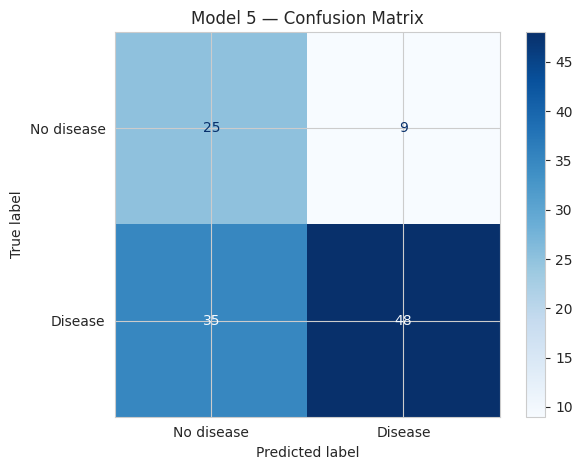

In [64]:
# Make the confusion matrix for this best model
# Get the predictions for the test set with model 4
pred5 = model5.predict(X_test)
# Make a confusion matrix of the predicted and actual values
cm_m5 = confusion_matrix(y_test, pred5)
# Make a variable that holds the display of the confusion matrix made above
disp_m5 = ConfusionMatrixDisplay(confusion_matrix=cm_m5, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_m5.plot(cmap='Blues')
plt.title('Model 5 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [65]:
# Print the classification report
print(classification_report(y_test, pred5, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.42      0.74      0.53        34
     Disease       0.84      0.58      0.69        83

    accuracy                           0.62       117
   macro avg       0.63      0.66      0.61       117
weighted avg       0.72      0.62      0.64       117



In [66]:
# Get the AUC score
y_test_proba5 = model5.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba5)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7381



ROC Curve (Test Set):


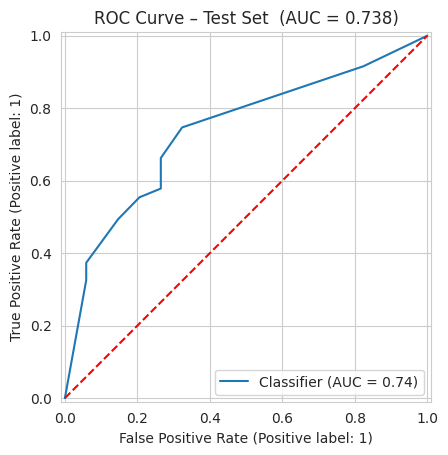

In [67]:
# Plot the ROC curve
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba5)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

This new model has higher precision on the positive class and higher recall on the negative class. However, it still predicts more false negatives than our best model from earlier (model 3). It has less overall incorrect predictions, but since there are more false negatives, it's not the ideal model for our purposes. This is an example of how sometimes there's a tradeoff between overall accuracy and another metric so that overall accuracy isn't always the best indicator of the best model.

### Final Best Model for Decision Trees and Corresponding Metrics

In [68]:
final_model = model3
print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


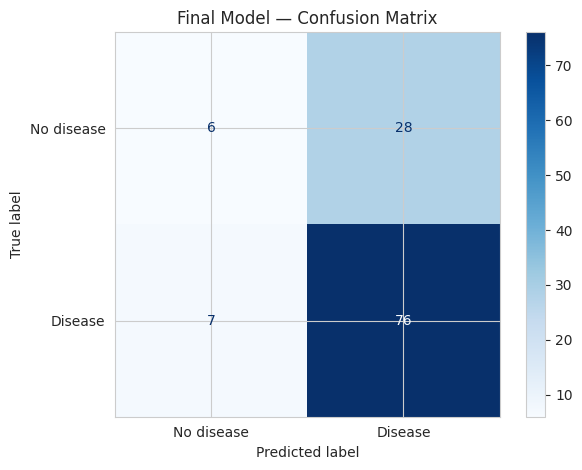

In [69]:
# Make the predictions on the test set
pred_f = final_model.predict(X_test)
# Make the confusion matrix comparing the actual and predicted values
cm_mf = confusion_matrix(y_test, pred_f)
# Make a variable that holds the display of the confusion matrix made above
disp_mf = ConfusionMatrixDisplay(confusion_matrix=cm_mf, display_labels=['No disease', 'Disease'])
# Plot the display of the confusion matrix
disp_mf.plot(cmap='Blues')
plt.title('Final Model — Confusion Matrix')
plt.tight_layout()
plt.show()

In [70]:
# Print the classification report
print(classification_report(y_test, pred_f, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.46      0.18      0.26        34
     Disease       0.73      0.92      0.81        83

    accuracy                           0.70       117
   macro avg       0.60      0.55      0.53       117
weighted avg       0.65      0.70      0.65       117



In [71]:
# Make the ROC curve and get the AUC score
y_test_proba_f = final_model.predict_proba(X_test)[:,1]
test_auc_f  = metrics.roc_auc_score(y_test, y_test_proba_f)
print(f'AUC score: {test_auc_f:.4f}')

AUC score: 0.7456



ROC Curve (Test Set):


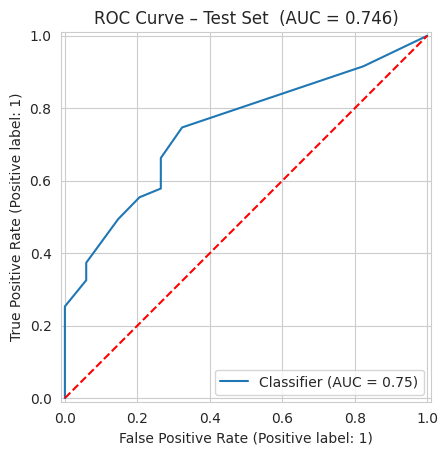

In [72]:
# Plot the ROC curve
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba_f)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc_f:.3f})')
plt.show()

### Most Important Features

Now, we will get the most important features in the decision tree.

In [73]:
# Get the feature importances for the classifier of our best model (model 3)
importances = model3.named_steps['classifier'].feature_importances_
print(importances)

[0.         0.         0.11088828 0.         0.         0.26343111
 0.08854489 0.         0.         0.         0.         0.45788417
 0.06529401 0.01395755 0.         0.        ]


In [74]:
# Print the order of the columns in X, but know that the one hot encoding will make the first two columns gender_male and gender_female in the
# decision tree, meaning that age is now the third column when shown in feature importances and every other column is one after the index shown
# here
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          583 non-null    int64  
 1   Gender       583 non-null    object 
 2   TB           583 non-null    float64
 3   DB           583 non-null    float64
 4   Alkphos      583 non-null    int64  
 5   Sgpt         583 non-null    int64  
 6   Sgot         583 non-null    int64  
 7   TP           583 non-null    float64
 8   ALB          583 non-null    float64
 9   A/G Ratio    583 non-null    float64
 10  TB_log       583 non-null    float64
 11  DB_log       583 non-null    float64
 12  Alkphos_log  583 non-null    float64
 13  Sgpt_log     583 non-null    float64
 14  Sgot_log     583 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 68.4+ KB


From comparing the feature importances to the columns, we can see that TB is the most important feature in determining if a patient has liver disease. Alkphos is the next most important feature, and then age. We can see that gender, Sgot, TP, ALB, and A/G Ratio have no impact on the model and the rest of the feaures only have a small impact on it. TB stands for Total Bilirubin level, and bilirubin is a waste product that's processed in the liver from the natural breakdown of red blood cells. High levels of it are known to indicate liver disease. The average level in healthy adults is 0.1 to 1.2 mg/dL, and this dataset had a mean level of about 3.3, so it makes sense that this would be a strong indicator of liver disease. Alkphos is an enzyme that's found in the body, but especially the liver, that breaks down protiens and aids in metabolic processes. It's also used frequently to detect liver disease, with average healthy levels being between 44 to 147 IU/L. For our dataset, the mean was 290.58, which again is out of healthy levels. As you get older, your liver shrinks, reduces bloodflow, and regenerates less, so it makes sense that age also contributed to the prediction from the model.

### Decision Tree Conclusion

The best final model for decision trees had a recall of 0.92 and a AUC score of 0.7456. This AUC score means that the model is considered acceptable because it's between 0.7 and 0.8. It is better than random guessing, and slightly higher than our prevalence, meaning that it's better than if you guessed that everyone had liver disease. Recall was the metric that we wanted to focus on the most, as false negatives would be really detrimental because they mean that someone who does have liver disease is told that they don't have it. The model still didn't guess that very many people didn't have liver disease due to the dataset being small and also having a high prevalence, so the model could benefit from being retrained with a larger, more diverse dataset that has an even distribution of patients with and without liver disease.

## Overall Conclusion of Models

Taking the results of our logistic regression and decision tree methods into account, the best model was ultimately Model 2 for Logistic Regression. This model incorporated all variables and included the log-transformed features. It had the best overall ROC-AUC value of 0.8455, as well as the lowest number of false negatives with only 3. Though it wasn't perfect by any means, it was the most accurate predictor of liver disease, and it showed that the best means of testing for disease is to analyze a combination of all clinical biomarkers together.

Our model can serve as a good starting point for doctors trying to diagnose liver disease, but it shouldn't lead to a definitive diagnosis. It works well enough on our test data to provide a baseline idea of whether or not a patient may have liver disease, but its issues prove to be a considerable limitation. Because of this, our model should only be used to identify whether a patient should be sent to extra testing at a further stage.

Since the dataset only contains information from patients in the northeast region of Andhra Pradesh, India, we can't confidently generalize it to people from other regions of the world due to possible regional differences in some of the levels that would lead to inaccurate classifications. We also don't know how well this captures overall trends due to the small size of the dataset, so additional testing on other datasets with the same features might be helpful. The model would also benefit from being retrained on a larger dataset with more of a balance between patients with and without liver disease, which would likely increase accuracy. More optimistically, the feature importances from our model can provide doctors with some useful insights, as they reveal which tests should be prioritized when attempting to diagnose a patient.

Overall, our final results suggest that liver disease can be predicted with reasonable accuracy using clinical biomarkers. In this case, no single feature is sufficient on its own, and predictive power ultimately comes from combining multiple indicators.

## Team Contribution

Our group collaborated throughout the project, but mainly distributed the workload by splitting it up into different sections. Maddie was tasked with developing the question and writing the background information paragraphs, then we all worked through data cleaning together. Maddie also completed the section on EDA, with graphs and explanations highlighting initial discoveries in the dataset. Ava and Maya each worked on our methods of logistic regression and decision trees, respectively. This involved building different models, analyzing the results using evaluation metrics, and writing a methods conclusion tying it back to our central question. Maddie then used both outcomes to develop a final conclusion between the models. We came together after finishing our sections to look over and combine our work, putting all of it into this notebook.